In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('Churn_Modelling.csv')
df.head(100)

Saving Churn_Modelling.csv to Churn_Modelling.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,15699461,Fiorentini,515,Spain,Male,35,10,176273.95,1,0,1,121277.78,0
96,97,15738721,Graham,773,Spain,Male,41,9,102827.44,1,0,1,64595.25,0
97,98,15693683,Yuille,814,Germany,Male,29,8,97086.40,2,1,1,197276.13,0
98,99,15604348,Allard,710,Spain,Male,22,8,0.00,2,0,0,99645.04,0


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df=pd.read_csv('Churn_Modelling.csv')
x=df.iloc[:,3:-1].values
y=df.iloc[:,-1].values
print(x,y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]] [1 0 1 ... 1 1 0]


In [6]:
le=LabelEncoder()
x_train[:,2]=le.fit_transform(x_train[:,2])
x_test[:,2]=le.fit_transform(x_test[:,2])
print(x_train,x_test)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[1])],remainder='passthrough')
x_train=np.array(ct.fit_transform(x_train))
x_test=np.array(ct.fit_transform(x_test))

[[686 'France' 1 ... 1 1 179093.26]
 [632 'Germany' 1 ... 1 1 195978.86]
 [559 'Spain' 1 ... 1 0 85891.02]
 ...
 [735 'France' 0 ... 0 0 92220.12]
 [667 'France' 1 ... 1 0 97508.04]
 [697 'Germany' 1 ... 1 1 53581.14]] [[596 'Germany' 1 ... 0 0 41788.37]
 [623 'France' 1 ... 1 1 146379.3]
 [601 'Spain' 0 ... 1 0 58561.31]
 ...
 [730 'France' 0 ... 1 0 33373.26]
 [692 'France' 1 ... 1 0 76755.99]
 [628 'Germany' 1 ... 1 1 107674.3]]


In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [8]:
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [9]:
model= keras.Sequential([
    keras.layers.Dense(128, input_shape=(x_train.shape[1],), activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=10, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8131 - loss: 0.4351
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8522 - loss: 0.3588
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8545 - loss: 0.3455
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8622 - loss: 0.3398
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8614 - loss: 0.3350
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8615 - loss: 0.3324
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8631 - loss: 0.3296
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8660 - loss: 0.3253
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8676 - loss: 0.3241
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8676 - loss: 0.3217


In [10]:
model.evaluate(x_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8555 - loss: 0.3425


[0.3424890637397766, 0.8554999828338623]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Text(95.72222222222221, 0.5, 'Truth')

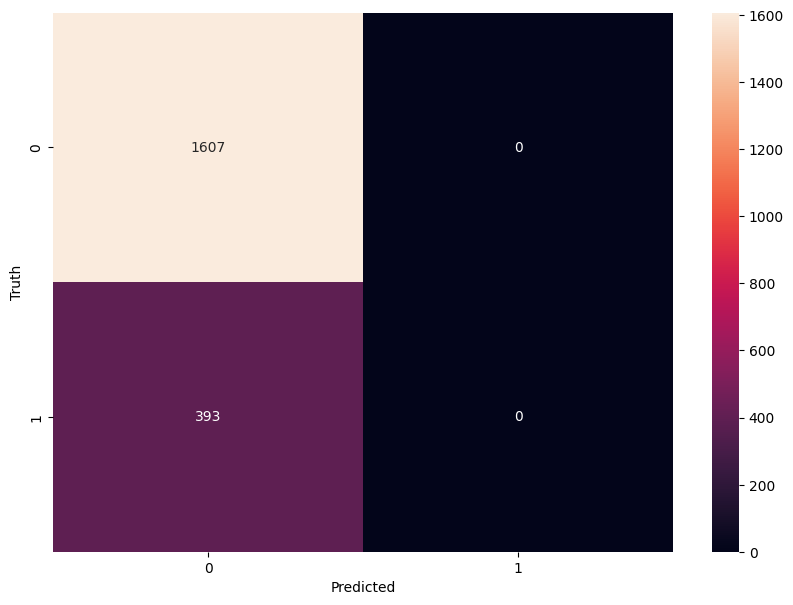

In [11]:
y_predicted= model.predict(x_test)
y_predicted=[np.argmax(i) for i in y_predicted]
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predicted)
cm
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [13]:
import numpy as np

# Take input
credit_score = int(input("Credit Score: "))
geography = input("Geography (France/Germany/Spain): ").title()
gender = input("Gender (Male/Female): ").title()
age = int(input("Age: "))
tenure = int(input("Tenure: "))
balance = float(input("Balance: "))
products = int(input("Number of Products: "))
card = int(input("Has Credit Card (0/1): "))
active = int(input("Is Active Member (0/1): "))
salary = float(input("Estimated Salary: "))

# Create input array
customer = np.array([[credit_score, geography, gender, age, tenure,
                      balance, products, card, active, salary]])

# Encode Gender
customer[:, 2] = le.transform(customer[:, 2])

# One-Hot Encode Geography
customer = ct.transform(customer)

# Scale the data
customer = sc.transform(customer)

# Predict
prediction = model.predict(customer)

# Display result
print("\nPrediction Probability:", prediction[0][0])

if prediction[0][0] >= 0.5:
    print("Customer will leave the bank.")
else:
    print("Customer will stay with the bank.")

Credit Score: 444
Geography (France/Germany/Spain): France
Gender (Male/Female): Male
Age: 23
Tenure: 9
Balance: 2340000
Number of Products: 1
Has Credit Card (0/1): 0
Is Active Member (0/1): 0
Estimated Salary: 23456
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Prediction Probability: 0.011287653
Customer will stay with the bank.


In [18]:
%%writefile app.py
import streamlit as st
import numpy as np

st.title("Customer Churn Prediction")

# Input widgets
credit_score = st.slider("Credit Score", 300, 900, 600)

geography = st.selectbox(
    "Geography",
    ["France", "Germany", "Spain"]
)

gender = st.selectbox(
    "Gender",
    ["Male", "Female"]
)

age = st.slider("Age", 18, 100, 30)

tenure = st.slider("Tenure", 0, 10, 5)

balance = st.slider(
    "Balance",
    0.0,
    250000.0,
    50000.0
)

products = st.slider(
    "Number of Products",
    1,
    4,
    2
)

card = st.selectbox(
    "Has Credit Card",
    [0,1]
)

active = st.selectbox(
    "Is Active Member",
    [0,1]
)

salary = st.slider(
    "Estimated Salary",
    0.0,
    200000.0,
    50000.0
)

if st.button("Predict"):

    customer = np.array([[credit_score,
                          geography,
                          gender,
                          age,
                          tenure,
                          balance,
                          products,
                          card,
                          active,
                          salary]])

    customer[:,2] = le.transform(customer[:,2])

    customer = ct.transform(customer)

    customer = sc.transform(customer)

    prediction = model.predict(customer)

    if prediction[0][0] >= 0.5:
        st.error("Customer is likely to leave the bank.")
    else:
        st.success("Customer is likely to stay with the bank.")

    st.write("Probability:", round(float(prediction[0][0]),2))

Writing app.py


In [17]:
!pip install -q streamlit
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 3s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧npm notice
npm notice New major version of npm available! 10.8.2 -> 11.18.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.18.0
npm notice To update run: npm install -g npm@11.18.0
npm notice
⠧

In [15]:
pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 51.9 MB/s eta 0:00:00
